**EL5206 Laboratorio de Inteligencia Computacional y Robótica**

In [33]:
import numpy as np
from matplotlib import pyplot as plt
import random
import math

In [34]:
# Cargamos los datos del laser
my_array = np.load('gt.npy')
#my_array = np.load('odom.npy')
print(my_array)

[[ 2.39060224  0.84330792]
 [ 2.32827095  0.85196129]
 [ 2.24272597  0.84676674]
 ...
 [ 6.1730913  -5.22984143]
 [ 6.23023698 -5.23765266]
 [ 6.28762084 -5.21214495]]


In [35]:
#Eliminamos los elementos que se van a infinito
new_array = []
for i in range(len(my_array)):

  if my_array[i][0] != np.inf:
    new_array.append(my_array[i])
new_array = np.array(new_array)

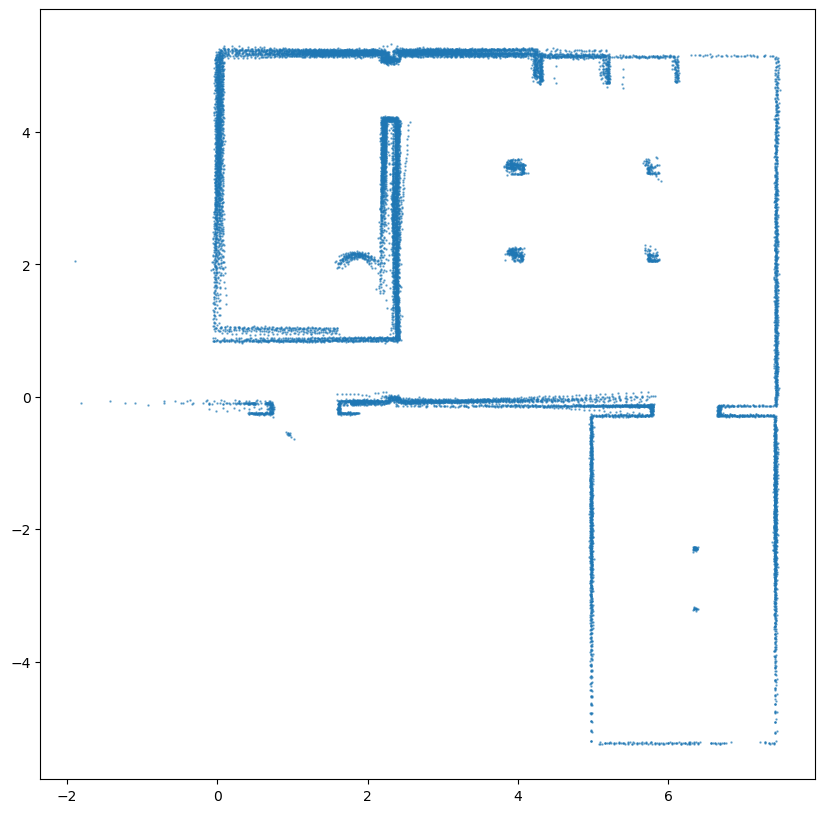

In [36]:
# Mostramos las mediciones en un gráfico
x = []
y = []
for i in range(len(new_array)):
  x.append(new_array[i][0])
  y.append(new_array[i][1])

cartesianas = new_array
plt.figure(figsize=(10,10)) 
plt.scatter(x, y, alpha=0.6, s=0.5)

plt.show()

In [37]:
def distancia_punto_a_recta(punto, m, n):
    # Calcula la distancia entre un punto y una recta
    x, y = punto
    distancia = np.abs(m * x - y + n) / np.sqrt(m**2 + 1)
    return distancia

In [38]:
def line_from_points(p1, p2):
    (x1, y1), (x2, y2) = p1, p2
  # COMPLETAR con la ecuación de la recta de toda la vida
  ## Recta a*x + b*y + c = 0 normalizada (c >= 0) a partir de 2 puntos.

    a = (y1 - y2) / (x2 -x1)
    b = 1
    c = -a*x1-y1
    norm = math.hypot(a, b)
    if norm == 0:
        return None
    a, b, c = a/norm, b/norm, c/norm
    if c < 0:  # consistencia de signos
        a, b, c = -a, -b, -c
    return (a, b, c)

In [39]:
def mn_from_abc(a, b, c):
    if b == 0:
        return float('inf'), float('inf')  # Línea vertical
    m = -a / b
    n = -c / b
    return m, n

In [46]:
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines):
    # COMPLETAR
        lines = []
        point_1 = random.choice(points)
        point_2 = random.choice(points)
        line = line_from_points(point_1, point_2)
        for i in range(max_iter):
            inliers = []
            for p in points:
                distance = abs(line[0]*p[0] + line[1]*p[1] + line[2])
                if distance < dist_thresh:
                    inliers.append(p)
            if len(inliers) >= min_inliers:
                lines.append(line)
                if len(lines) >= max_lines:
                    break
                points = [tuple(p) for p in points]
                points = [p for p in points if p not in inliers]
            point_1 = random.choice(points)
            point_2 = random.choice(points)
            line = line_from_points(point_1, point_2)

            mn = mn_from_abc(line[0], line[1], line[2])
        return mn


In [54]:
def RANSAC(points, dist_thresh, min_inliers, max_iter, max_lines):
    lines = []
    points = np.array(points)  # aseguramos que es array numpy

    for _ in range(max_iter):
        if len(points) < 2:  # no quedan suficientes puntos
            break

        # Elegimos dos puntos aleatorios
        idx = np.random.choice(len(points), 2, replace=False)
        point_1, point_2 = points[idx]

        # Ecuación de la recta
        line = line_from_points(point_1, point_2)
        if line is None:
            continue

        # Distancia de todos los puntos a la recta
        distances = np.abs(line[0]*points[:,0] + line[1]*points[:,1] + line[2])

        # Inliers y outliers
        inliers_mask = distances < dist_thresh
        inliers = points[inliers_mask]
        points = points[~inliers_mask]  # descartamos los inliers

        # Guardamos línea si tiene suficientes inliers
        if len(inliers) >= min_inliers:
            lines.append(line)
            if len(lines) >= max_lines:
                break

    mn_list = []
    for line in lines:
        mn = mn_from_abc(line[0], line[1], line[2])
        mn_list.append(mn)
    return mn_list


[(-12.149297406046035, 30.535251058303338), (-0.09739629284859237, 5.3706550166351334), (-0.008964336363316129, 5.214423617994034), (25.15296603052435, -58.427160937716394), (188.01900753550012, -936.8948985250557), (-34.10450139015814, 83.02879901863703), (-0.04250015072099791, 0.014140875906678452), (-0.02401857741430403, 5.254163150239858), (8789.327757686762, -65272.127484614306), (91.91675373732876, -219.13289542119963), (0.016097665920292683, 5.1949332070616965), (0.014552979425703667, 5.145268335870052), (191.44569543833018, -1420.4879472862892), (-0.0008966695555276921, 5.220116555755178), (-0.02328504784726955, 0.0173987118342869), (17.377030054735307, 3.6250882824881927), (246.1932239951468, -1831.6851032225027), (106.75622218840859, -253.1166368277071), (0.007175104572279056, 5.114078428947562), (-114.10681286165025, 5.5630573944687125)]


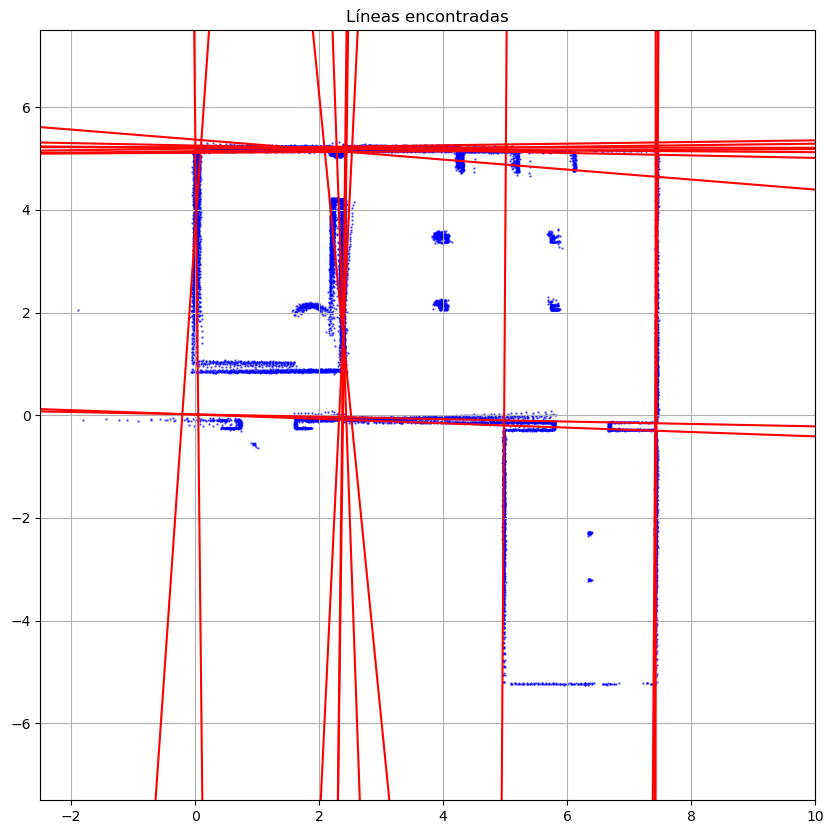

In [197]:
dist_tresh = 0.005
min_inliers = 100
max_iter = 10000
max_lines = 20
mn = RANSAC(cartesianas, dist_tresh, min_inliers, max_iter, max_lines)
print(mn)

plt.figure(figsize=(10,10))
plt.xlim(-2.5,10)
plt.ylim(-7.5,7.5)

for line in mn:
    m, n = line
    x = np.linspace(-10, 10, 100)
    y = m * x + n
    plt.plot(x, y, color='red')

px = []
py = []

for x in cartesianas:
  px.append(x[0])
  py.append(x[1])
plt.scatter(px, py, color = 'blue', alpha=0.6, s=0.5)

plt.title('Líneas encontradas')
plt.grid(True)
plt.show()